Danna isabella cardenas-2241361

In [ ]:
import sympy as sp

# 1. Variable y límites
x = sp.symbols('x')
a, b = -1, 1

# 2. Base de monomios
base = [sp.Matrix([1]), sp.Matrix([x]), sp.Matrix([x**2]), sp.Matrix([x**3]), sp.Matrix([x**4])]

# 3. Producto interno <f|g> = ∫ f(x)g(x) dx
def producto(f, g):
    return sp.integrate(f[0]*g[0], (x, a, b))

# 4. Verificación de ortogonalidad
ortogonales = True
for i, vi in enumerate(base):
    for j, vj in enumerate(base):
        if j > i:
            resultado = producto(vi, vj)
            print(f"Producto interno entre P{i} y P{j}: {resultado}")
            if resultado != 0:
                ortogonales = False

# 5. Mostrar conclusión
if ortogonales:
    print("El conjunto de monomios es ortogonal bajo este producto interno.")
else:
    print("El conjunto de monomios NO es ortogonal bajo este producto interno.")


Producto interno entre P0 y P1: 0
Producto interno entre P0 y P2: 2/3
Producto interno entre P0 y P3: 0
Producto interno entre P0 y P4: 2/5
Producto interno entre P1 y P2: 0
Producto interno entre P1 y P3: 2/5
Producto interno entre P1 y P4: 0
Producto interno entre P2 y P3: 0
Producto interno entre P2 y P4: 2/7
Producto interno entre P3 y P4: 0
El conjunto de monomios NO es ortogonal bajo este producto interno.


In [6]:
import sympy as sp
from sympy import symbols, integrate, simplify, sqrt, Matrix

# -----------------------------
# PROCESO DE GRAM-SCHMIDT
# -----------------------------
def gram_schmidt(base, producto_interno, normalizar=False):
    """
    Aplica Gram-Schmidt para ortogonalizar (y opcionalmente normalizar) una base de polinomios.
    """
    ortogonales = []
    for v in base:
        u = v.copy()
        # Restamos las proyecciones sobre los vectores ya ortogonalizados
        for w in ortogonales:
            num = producto_interno(v, w)       # ⟨v|w⟩
            den = producto_interno(w, w)       # ⟨w|w⟩
            if den != 0:
                u = u - (num/den) * w
        ortogonales.append(simplify(u))

    # Normalización opcional (P_n(1)=1)
    if normalizar:
        x = symbols('x')
        norm = []
        for p in ortogonales:
            factor = p[0].subs(x, 1)
            norm.append(simplify(p/factor) if factor != 0 else p)
        return norm
    return ortogonales

# -----------------------------
# VERIFICAR ORTOGONALIDAD
# -----------------------------
def verificar_ortogonalidad(vectores, producto_interno, nombre="P"):
    """
    Verifica si los vectores obtenidos son ortogonales (⟨vi|vj⟩ = 0 para i≠j).
    """
    n = len(vectores)
    es_ortogonal = True
    for i in range(n):
        for j in range(i+1, n):
            val = producto_interno(vectores[i], vectores[j]).evalf()
            if abs(val) > 1e-12:
                print(f"⟨{nombre}_{i}|{nombre}_{j}⟩ = {val}  → NO ortogonales ❌")
                es_ortogonal = False
            else:
                print(f"⟨{nombre}_{i}|{nombre}_{j}⟩ ≈ 0 ✓")
    return es_ortogonal

# -----------------------------
# POLINOMIOS DE LEGENDRE
# -----------------------------
def polinomios_legendre(n=10):
    """
    Calcula los primeros n polinomios de Legendre con Gram-Schmidt.
    """
    x = symbols('x')
    base = [Matrix([x**i]) for i in range(n)]   # base de monomios: 1, x, x², ...

    # Definimos el producto interno de Legendre: ⟨f|g⟩ = ∫ f(x)g(x) dx en [-1,1]
    def producto(f, g):
        return integrate(f[0]*g[0], (x, -1, 1))

    polinomios = gram_schmidt(base, producto, normalizar=True)

    print("\nPolinomios de Legendre:")
    for i, p in enumerate(polinomios):
        print(f"P_{i}(x) = {simplify(p[0])}")

    verificar_ortogonalidad(polinomios, producto, "P")
    return polinomios

# -----------------------------
# POLINOMIOS DE CHEBYSHEV
# -----------------------------
def polinomios_chebyshev(n=10):
    """
    Calcula los primeros n polinomios de Chebyshev con Gram-Schmidt.
    """
    x = symbols('x')
    base = [Matrix([x**i]) for i in range(n)]

    # Producto interno de Chebyshev: ⟨f|g⟩ = ∫ f(x)g(x)/√(1-x²) dx en [-1,1]
    def producto(f, g):
        return integrate(f[0]*g[0]/sqrt(1-x**2), (x, -1, 1))

    polinomios = gram_schmidt(base, producto, normalizar=True)

    print("\nPolinomios de Chebyshev:")
    for i, p in enumerate(polinomios):
        print(f"T_{i}(x) = {simplify(p[0])}")

    verificar_ortogonalidad(polinomios, producto, "T")
    return polinomios

# -----------------------------
# MAIN
# -----------------------------
if __name__ == "__main__":
    print("=== ORTOGONALIZACIÓN DE POLINOMIOS (Primeros 10) ===")
    legendre = polinomios_legendre(10)   # primeros 10 polinomios de Legendre
    chebyshev = polinomios_chebyshev(10) # primeros 10 polinomios de Chebyshev


=== ORTOGONALIZACIÓN DE POLINOMIOS (Primeros 10) ===

Polinomios de Legendre:
P_0(x) = 1
P_1(x) = x
P_2(x) = 3*x**2/2 - 1/2
P_3(x) = x*(5*x**2 - 3)/2
P_4(x) = 35*x**4/8 - 15*x**2/4 + 3/8
P_5(x) = x*(63*x**4 - 70*x**2 + 15)/8
P_6(x) = 231*x**6/16 - 315*x**4/16 + 105*x**2/16 - 5/16
P_7(x) = x*(429*x**6 - 693*x**4 + 315*x**2 - 35)/16
P_8(x) = 6435*x**8/128 - 3003*x**6/32 + 3465*x**4/64 - 315*x**2/32 + 35/128
P_9(x) = x*(12155*x**8 - 25740*x**6 + 18018*x**4 - 4620*x**2 + 315)/128
⟨P_0|P_1⟩ ≈ 0 ✓
⟨P_0|P_2⟩ ≈ 0 ✓
⟨P_0|P_3⟩ ≈ 0 ✓
⟨P_0|P_4⟩ ≈ 0 ✓
⟨P_0|P_5⟩ ≈ 0 ✓
⟨P_0|P_6⟩ ≈ 0 ✓
⟨P_0|P_7⟩ ≈ 0 ✓
⟨P_0|P_8⟩ ≈ 0 ✓
⟨P_0|P_9⟩ ≈ 0 ✓
⟨P_1|P_2⟩ ≈ 0 ✓
⟨P_1|P_3⟩ ≈ 0 ✓
⟨P_1|P_4⟩ ≈ 0 ✓
⟨P_1|P_5⟩ ≈ 0 ✓
⟨P_1|P_6⟩ ≈ 0 ✓
⟨P_1|P_7⟩ ≈ 0 ✓
⟨P_1|P_8⟩ ≈ 0 ✓
⟨P_1|P_9⟩ ≈ 0 ✓
⟨P_2|P_3⟩ ≈ 0 ✓
⟨P_2|P_4⟩ ≈ 0 ✓
⟨P_2|P_5⟩ ≈ 0 ✓
⟨P_2|P_6⟩ ≈ 0 ✓
⟨P_2|P_7⟩ ≈ 0 ✓
⟨P_2|P_8⟩ ≈ 0 ✓
⟨P_2|P_9⟩ ≈ 0 ✓
⟨P_3|P_4⟩ ≈ 0 ✓
⟨P_3|P_5⟩ ≈ 0 ✓
⟨P_3|P_6⟩ ≈ 0 ✓
⟨P_3|P_7⟩ ≈ 0 ✓
⟨P_3|P_8⟩ ≈ 0 ✓
⟨P_3|P_9⟩ ≈ 0 ✓
⟨P_4|P_5⟩ ≈ 0 ✓
⟨P_4|P_6⟩ ≈ 0 ✓
⟨P_4|P_

In [7]:
import sympy
from sympy import *

import numpy as np
import matplotlib.pyplot as plt
#1-Define la variable simbólica t y el intervalo [-1, 1]
t = symbols('t')
a, b = -1, 1
#2. Base de monomios-Crea una base de 10 monomios: {1, t, t², ..., t⁹}
base = [Matrix([1]), Matrix([t]), Matrix([t**2]), Matrix([t**3]), Matrix([t**4]), Matrix([t**5]), Matrix([t**6]), Matrix([t**7]), Matrix([t**8]), Matrix([t**9])]
#3. Productos internos-Producto 1: ∫f·g dt (producto interno estándar L²)-Producto 2: ∫f·g·√(1-t²) dt (producto interno ponderado)
def producto1(f, g):
    return integrate(f[0]*g[0], (t,a,b))

def producto2(f, g):
    return integrate(f[0]*g[0]*sqrt(1-t**2), (t,a,b))
#4. Verificación de ortogonalidad-Comprueba si los monomios son ortogonales entre sí
ortogonales = True
for i, vi in enumerate(base):
    for j, vj in enumerate(base):
        if j > i:
            resultado1 = producto1(vi,vj)
            print(f"Producto interno 1 entre P{i} y P{j}: {resultado1}")
            if resultado1 != 0:
                ortogonales = False
if ortogonales:
    print("a) El conjunto es ortogonal bajo el producto 1")
else:
    print("a) El conjunto no es ortogonal bajo el producto 1")

#5. Proceso de Gram-Schmidt (Producto 1)-Aplica el algoritmo de Gram-Schmidt-Para cada nuevo vector, resta sus proyecciones sobre todos los vectores ya ortogonalizados-Resultado: Polinomios de Legendre
ortogonales1 = []
for v in base:
    u = v
    for o in ortogonales1:
        u -= (producto1(v,o) / producto1(o,o)) * o
    ortogonales1.append(u)
legendre10 = FiniteSet(*ortogonales1)
print("b) Polinomios de Legendre:",  legendre10)

#6. Proceso de Gram-Schmidt (Producto 2)-Mismo proceso pero con el producto ponderado-Resultado: Polinomios de Chebyshev
ortogonales2 = []
for v in base:
    u = v
    for o in ortogonales2:
        u -= (producto2(v,o) / producto2(o,o)) * o
    ortogonales2.append(u)
chebyshev10 = FiniteSet(*ortogonales2)
print("c) Polinomios de Chebyshev:", chebyshev10)

Producto interno 1 entre P0 y P1: 0
Producto interno 1 entre P0 y P2: 2/3
Producto interno 1 entre P0 y P3: 0
Producto interno 1 entre P0 y P4: 2/5
Producto interno 1 entre P0 y P5: 0
Producto interno 1 entre P0 y P6: 2/7
Producto interno 1 entre P0 y P7: 0
Producto interno 1 entre P0 y P8: 2/9
Producto interno 1 entre P0 y P9: 0
Producto interno 1 entre P1 y P2: 0
Producto interno 1 entre P1 y P3: 2/5
Producto interno 1 entre P1 y P4: 0
Producto interno 1 entre P1 y P5: 2/7
Producto interno 1 entre P1 y P6: 0
Producto interno 1 entre P1 y P7: 2/9
Producto interno 1 entre P1 y P8: 0
Producto interno 1 entre P1 y P9: 2/11
Producto interno 1 entre P2 y P3: 0
Producto interno 1 entre P2 y P4: 2/7
Producto interno 1 entre P2 y P5: 0
Producto interno 1 entre P2 y P6: 2/9
Producto interno 1 entre P2 y P7: 0
Producto interno 1 entre P2 y P8: 2/11
Producto interno 1 entre P2 y P9: 0
Producto interno 1 entre P3 y P4: 0
Producto interno 1 entre P3 y P5: 2/9
Producto interno 1 entre P3 y P6: 0
Pr

APROXIMACIÓN CON BASE DE MONOMIOS

APROXIMACIÓN CON POLINOMIOS DE LEGENDRE
Grado 0: Error = 2.702723e-01
Grado 1: Error = 1.523126e-01
Grado 2: Error = 1.523126e-01

APROXIMACIÓN CON POLINOMIOS DE CHEBYSHEV


PrintMethodNotImplementedError: Unsupported by <class 'sympy.printing.numpy.NumPyPrinter'>: <class 'sympy.integrals.integrals.Integral'>
Set the printer option 'strict' to False in order to generate partially printed code.

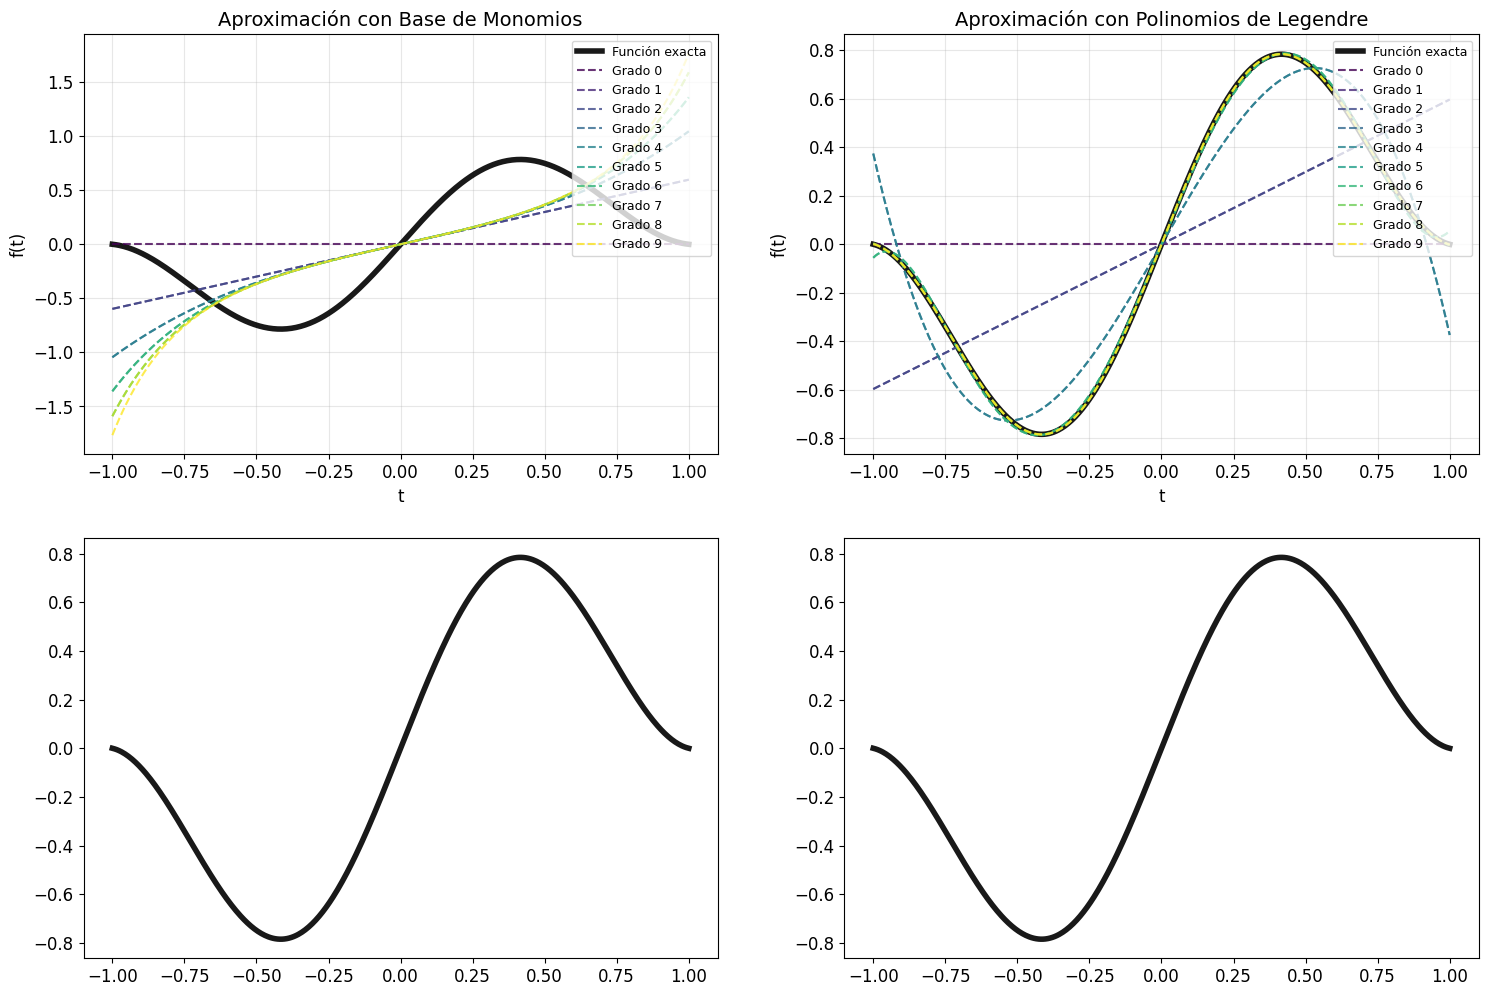

In [8]:
import sympy
from sympy import *
import numpy as np
import matplotlib.pyplot as plt

# Configuración para mostrar gráficas
plt.rcParams['figure.figsize'] = [18, 12]
plt.rcParams['font.size'] = 12

# Variables y límites de integración
t = symbols('t')
a, b = -1, 1

# Defino base de monomios
base = [Matrix([1]), Matrix([t]), Matrix([t**2]), Matrix([t**3]), Matrix([t**4]),
        Matrix([t**5]), Matrix([t**6]), Matrix([t**7]), Matrix([t**8]), Matrix([t**9])]

# Defino productos internos
def producto1(f, g):
    return integrate(f[0]*g[0], (t, a, b))  # Para Legendre

def producto2(f, g):
    return integrate(f[0]*g[0]*sqrt(1-t**2), (t, a, b))  # Para Chebyshev

# Función a aproximar
h_expr = sin(3*t)*(1-t**2)
h = [Matrix([h_expr])]

# Convertir función exacta a numérica
h_func = lambdify(t, h_expr, 'numpy')
t_vals = np.linspace(-1, 1, 500)
h_vals = h_func(t_vals)

# Proceso de Gram-Schmidt para Legendre
ortogonales_legendre = []
for v in base:
    u = v.copy()
    for o in ortogonales_legendre:
        proj = (producto1(v, o) / producto1(o, o)) * o
        u -= proj
    ortogonales_legendre.append(u)

# Proceso de Gram-Schmidt para Chebyshev
ortogonales_chebyshev = []
for v in base:
    u = v.copy()
    for o in ortogonales_chebyshev:
        proj = (producto2(v, o) / producto2(o, o)) * o
        u -= proj
    ortogonales_chebyshev.append(u)

# Crear figura con 3 subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Graficar función exacta en todos los subplots
for ax in axes:
    ax.plot(t_vals, h_vals, 'k-', linewidth=4, label='Función exacta', alpha=0.9)

# Colores para diferentes grados
colors = plt.cm.viridis(np.linspace(0, 1, 10))

# Almacenar errores
errores_legendre = []
errores_chebyshev = []
errores_monomios = []

# 1. APROXIMACIÓN CON MONOMIOS (BASE ORIGINAL)
print("="*60)
print("APROXIMACIÓN CON BASE DE MONOMIOS")
print("="*60)
for grado in range(10):
    # Calcular coeficientes
    coef_grado = []
    for i in range(grado + 1):
        c1i = producto1(h, base[i]) / producto1(base[i], base[i])
        coef_grado.append(c1i[0])

    # Construir aproximación
    aproximacion = 0
    for i, c in enumerate(coef_grado):
        aproximacion += c * t**i

    # Convertir a numérica
    aprox_func = lambdify(t, aproximacion, 'numpy')
    aprox_vals = aprox_func(t_vals)
    if np.isscalar(aprox_vals):
        aprox_vals = np.full_like(t_vals, aprox_vals)

    # Calcular error
    error = np.mean((h_vals - aprox_vals)**2)
    errores_monomios.append(error)

    # Graficar
    axes[0].plot(t_vals, aprox_vals, color=colors[grado], linestyle='--',
                linewidth=1.5, label=f'Grado {grado}', alpha=0.8)

axes[0].set_title('Aproximación con Base de Monomios', fontsize=14)
axes[0].set_xlabel('t')
axes[0].set_ylabel('f(t)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', fontsize=9)

# 2. APROXIMACIÓN CON POLINOMIOS DE LEGENDRE
print("\n" + "="*60)
print("APROXIMACIÓN CON POLINOMIOS DE LEGENDRE")
print("="*60)
for grado in range(10):
    # Calcular coeficientes
    coef_grado = []
    for i in range(grado + 1):
        c1i = producto1(h, ortogonales_legendre[i]) / producto1(ortogonales_legendre[i], ortogonales_legendre[i])
        coef_grado.append(c1i[0])

    # Construir aproximación
    aproximacion = 0
    for i, c in enumerate(coef_grado):
        aproximacion += c * ortogonales_legendre[i][0]  # Usar polinomios de Legendre

    # Convertir a numérica
    aprox_func = lambdify(t, aproximacion, 'numpy')
    aprox_vals = aprox_func(t_vals)
    if np.isscalar(aprox_vals):
        aprox_vals = np.full_like(t_vals, aprox_vals)

    # Calcular error
    error = np.mean((h_vals - aprox_vals)**2)
    errores_legendre.append(error)

    # Graficar
    axes[1].plot(t_vals, aprox_vals, color=colors[grado], linestyle='--',
                linewidth=1.5, label=f'Grado {grado}', alpha=0.8)

    if grado <= 2:
        print(f"Grado {grado}: Error = {error:.6e}")

axes[1].set_title('Aproximación con Polinomios de Legendre', fontsize=14)
axes[1].set_xlabel('t')
axes[1].set_ylabel('f(t)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right', fontsize=9)

# 3. APROXIMACIÓN CON POLINOMIOS DE CHEBYSHEV
print("\n" + "="*60)
print("APROXIMACIÓN CON POLINOMIOS DE CHEBYSHEV")
print("="*60)
for grado in range(10):
    # Calcular coeficientes
    coef_grado = []
    for i in range(grado + 1):
        c1i = producto2(h, ortogonales_chebyshev[i]) / producto2(ortogonales_chebyshev[i], ortogonales_chebyshev[i])
        coef_grado.append(c1i[0])

    # Construir aproximación
    aproximacion = 0
    for i, c in enumerate(coef_grado):
        aproximacion += c * ortogonales_chebyshev[i][0]  # Usar polinomios de Chebyshev

    # Convertir a numérica
    aprox_func = lambdify(t, aproximacion, 'numpy')
    aprox_vals = aprox_func(t_vals)
    if np.isscalar(aprox_vals):
        aprox_vals = np.full_like(t_vals, aprox_vals)

    # Calcular error
    error = np.mean((h_vals - aprox_vals)**2)
    errores_chebyshev.append(error)

    # Graficar
    axes[2].plot(t_vals, aprox_vals, color=colors[grado], linestyle='--',
                linewidth=1.5, label=f'Grado {grado}', alpha=0.8)

    if grado <= 2:
        print(f"Grado {grado}: Error = {error:.6e}")

axes[2].set_title('Aproximación con Polinomios de Chebyshev', fontsize=14)
axes[2].set_xlabel('t')
axes[2].set_ylabel('f(t)')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right', fontsize=9)

# 4. COMPARACIÓN DE ERRORES
axes[3].plot(range(10), errores_monomios, 'bo-', linewidth=2, markersize=6, label='Monomios')
axes[3].plot(range(10), errores_legendre, 'ro-', linewidth=2, markersize=6, label='Legendre')
axes[3].plot(range(10), errores_chebyshev, 'go-', linewidth=2, markersize=6, label='Chebyshev')
axes[3].set_yscale('log')
axes[3].set_xlabel('Grado del polinomio')
axes[3].set_ylabel('Error Cuadrático Medio (log)')
axes[3].set_title('Comparación de Errores por Tipo de Base', fontsize=14)
axes[3].grid(True, alpha=0.3)
axes[3].legend()
axes[3].set_xticks(range(10))

# Añadir valores de error en el gráfico
for i, (err_m, err_l, err_c) in enumerate(zip(errores_monomios, errores_legendre, errores_chebyshev)):
    if i % 2 == 0:  # Mostrar solo algunos para no saturar
        axes[3].text(i, err_m*1.5, f'{err_m:.1e}', ha='center', va='bottom', fontsize=8, color='blue')
        axes[3].text(i, err_l*0.7, f'{err_l:.1e}', ha='center', va='top', fontsize=8, color='red')
        axes[3].text(i, err_c*1.2, f'{err_c:.1e}', ha='center', va='bottom', fontsize=8, color='green')

plt.tight_layout()
plt.show()

# RESUMEN FINAL
print("\n" + "="*80)
print("RESUMEN COMPARATIVO FINAL")
print("="*80)
print(f"{'Grado':<6} {'Monomios':<12} {'Legendre':<12} {'Chebyshev':<12} {'Mejor':<8}")
print("-"*80)

for grado in range(10):
    errors = [errores_monomios[grado], errores_legendre[grado], errores_chebyshev[grado]]
    best_idx = np.argmin(errors)
    best_method = ['Monomios', 'Legendre', 'Chebyshev'][best_idx]

    print(f"{grado:<6} {errores_monomios[grado]:<12.2e} {errores_legendre[grado]:<12.2e} "
          f"{errores_chebyshev[grado]:<12.2e} {best_method:<8}")

print("="*80)

# Mostrar primeros polinomios de cada base
print("\nPrimeros polinomios de Legendre:")
for i, p in enumerate(ortogonales_legendre[:4]):
    print(f"P{i}(t) = {simplify(p[0])}")

print("\nPrimeros polinomios de Chebyshev:")
for i, p in enumerate(ortogonales_chebyshev[:4]):
    print(f"T{i}(t) = {simplify(p[0])}")